# LLM: от предобучения до RLHF

In [1]:
!unzip lesson.zip

Archive:  lesson.zip
   creating: data/
  inflating: data/instruction-data-with-response.json  
  inflating: data/instruction-data.json  
  inflating: lesson.ipynb            
  inflating: requirements.txt        
   creating: scripts/
   creating: scripts/__pycache__/
  inflating: scripts/__pycache__/gpt_download.cpython-311.pyc  
  inflating: scripts/__pycache__/gpt_model.cpython-311.pyc  
  inflating: scripts/gpt_download.py  
  inflating: scripts/gpt_model.py    


In [ ]:
# %pip install \
# accelerate==1.10.1 \
# bitsandbytes==0.48.1 \
# importlib-metadata==8.7.0 \
# matplotlib==3.10.7 \
# peft==0.17.1 \
# psutil==7.1.0 \
# safetensors==0.6.2 \
# tiktoken==0.12.0 \
# tokenizers==0.22.1 \
# torch==2.8.0 \
# tqdm==4.67.1 \
# transformers==4.56.2 \
# trl==0.23.0 \
# unsloth==2025.10.1 \
# unsloth_zoo==2025.10.1


- В первой части урока мы реализуем цикл обучения и код для базовой оценки модели, чтобы выполнить её претренировку (pretraining).
- Также мы загрузим в нашу модель открыто доступные предобученные веса от OpenAI.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/chapter-overview.webp" width=1500px>

### Темы урока


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model--0.webp" width=800px>

## 1.1 Оценка генеративных текстовых моделей

- Посмотрим, как инициализировать модель GPT на основе кода из скрипта.
- Посмотрим на базовые метрики оценки для LLM.
- Применим эти метрики к обучающему и валидационному наборам данных.

### 1.1.1 Используем GPT для генерации текста
- Инициализируем модель GPT, используя код:

In [ ]:
import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

- В примере выше мы используем `dropout = 0.1`, но сегодня LLM часто обучают вообще без dropout.
- В современных LLM для слоёв `nn.Linear`, формирующих матрицы query/key/value, обычно не используют смещения (bias). Это настраивается флагом `"qkv_bias": False` (в отличие от ранних версий GPT).
- Мы уменьшаем длину контекста (`context_length`) до 256 токенов, чтобы снизить требования к ресурсам при обучении модели (у оригинальной GPT-2 с 124M параметров было 1024 токена).
  - Так можно повторить и запустить примеры на обычном ноутбуке.
  - При желании можете увеличить `context_length` до 1024 — код менять не нужно.
  - Позже в уроке мы также загрузим предобученную модель с контекстом 1024.

- Далее используем функцию `generate_text_simple` для генерации текста.
- Дополнительно определим две вспомогательные функции для конвертаций, которые будем использовать по всему уроку:
  - `text_to_token_ids` — перевод текста в идентификаторы токенов;
  - `token_ids_to_text` — обратное преобразование идентификаторов токенов в текст.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/gpt-process.webp" width=800px>

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [ ]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- Как видно выше, модель генерирует слабый текст — она ещё не обучена.
- Как численно зафиксировать, что такое «хороший текст», чтобы отслеживать это во время обучения?
- В следующем подпункте мы введем метрики и вычислим функцию потерь для сгенерированных выходов — её будем использовать как главный индикатор прогресса обучения.

<br>

### 1.1.2 Подсчёт loss для генерации текста: кросс-энтропия и перплексия

- Пусть у нас есть тензор `inputs` с ID токенов для двух обучающих примеров (строки).
- Ему соответствуют `targets` — это нужные ID токенов, которые модель должна предсказывать.
- Обратите внимание: `targets` — это `inputs`, сдвинутые на 1 позицию вправо.

In [ ]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- Прогоняя `inputs` через модель, получаем тензор логитов для 2 входных примеров по 3 токена каждый.
- Каждый токен представлен вектором размерности 50 257 — это размер словаря.
- Применяя функцию softmax, преобразуем тензор логитов в тензор той же формы с вероятностями по каждому токену.


In [ ]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- На схеме ниже (для наглядности используется очень маленький словарь) показано, как мы преобразуем вероятности обратно в текст .



<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/proba-to-text.webp" width=800px>

- Мы можем применить функцию `argmax`, чтобы преобразовать вероятности в предсказанные ID токенов.
- Выше softmax выдаёт для каждого токена вектор размерности 50 257; `argmax` возвращает позицию максимальной вероятности в этом векторе — это и есть предсказанный ID для данного токена.


- Так как у нас 2 батча по 3 токена, получаем матрицу предсказанных ID размером 2 × 3 (по одному ID на каждый токен каждого примера).


In [ ]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- Если декодировать эти токены обратно в текст, увидим, что они заметно отличаются от тех токенов, которые модель должна предсказывать, то есть от целевых (`targets`).


In [ ]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- Это потому, что модель ещё не обучена.
- Чтобы начать обучение, нам нужно количественно измерить, насколько предсказания далеки от целевых (`targets`) — далее введём функцию потерь для этой цели.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/proba-index.webp" width=800px>

- Вероятности токенов, соответствующие целевым индексам (`targets`), таковы:


In [ ]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


- Наша цель — максимизировать эти значения, стремясь к вероятности 1 для правильного токена.
- В оптимизации удобнее максимизировать логарифм вероятности, а не саму вероятность. Дополнительное объяснение см. в лекции: [L8.2 Logistic Regression Loss Function](https://www.youtube.com/watch?v=GxJe0DZvydM).


In [ ]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- Далее вычисляем средний логарифм вероятности (average log-probability):

In [ ]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- Наша цель — сделать средний логарифм вероятности как можно больше, оптимизируя веса модели.
- Из-за свойства логарифма его максимальное значение — это 0, и сейчас мы далеки от 0.





- В глубоких нейросетях вместо максимизации среднего логарифма вероятности принято минимизировать отрицательное среднее лог-правдоподобие.
  - То есть вместо «максимизировать −10.7940, приближая его к 0», мы «минимизируем 10.7940, приближая его к 0».
- Это значение (10.7940), то есть минус среднего лог-правдоподобия, в DL обычно называют кросс-энтропией (cross-entropy loss).

In [ ]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


- В PyTorch уже есть функция `torch.nn.functional.cross_entropy`, которая выполняет все описанные выше шаги

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/cross-entropy.webp?123" width=800px>

- Прежде чем применять `cross_entropy`, проверим формы тензоров логитов и целей

In [ ]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- Для `torch.nn.functional.cross_entropy` удобно сплющить тензоры по измерениям батча и длины последовательности:

In [ ]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- Обратите внимание: `targets` — это ID токенов, то есть индексы в тензоре логитов, вероятности по которым мы хотим максимизировать.
- Функция `torch.nn.functional.cross_entropy` автоматически выполнит всё под капотом: применит `softmax`, возьмёт лог-вероятности и рассчитает значение по тем индексам токенов в логитах, которые должны быть максимальны (то есть по `targets`).


In [ ]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


- С понятием кросс-энтропии тесно связана метрика перплексия (perplexity) для LLM.
- Перплексия — это просто экспонента от значения кросс-энтропии: `perplexity = exp(cross_entropy_loss)`.


In [ ]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


- Перплексия часто считается более интерпретируемой метрикой, потому что её можно понимать как эффективный размер словаря, в котором модель «неопределённа» на каждом шаге (в примере выше это было бы 48 725 слов или токенов).
- Иными словами, перплексия измеряет, насколько хорошо распределение вероятностей, предсказанное моделью, совпадает с реальным распределением слов в датасете.
- Как и для функции потерь, более низкая перплексия означает, что предсказания модели ближе к реальному распределению.


### 1.1.3 Подсчёт лоссов на обучающем и валидационном наборах

- Мы используем относительно небольшой датасет для обучения LLM (фактически, всего один короткий рассказ).
- Причины:
  - Вы сможете запустить примеры кода за считанные минуты на ноутбуке без подходящего GPU.
  - Обучение завершается довольно быстро (минуты вместо недель), что удобно в учебных целях.
  - Мы используем текст из публичного домена, который можно включить в репозиторий GitHub без нарушения прав и без раздувания размера репозитория.

- Например, Llama 2 7B потребовала 184 320 GPU-часов на A100 для обучения на 2 трлн токенов.
  - Стоимость аренды облачного сервера AWS с 8×A100 примерно \$30 в час.
  - Приблизительная оценка: обучение такой LLM обойдётся в 184 320 / 8 * \$30 = \$690 000.




In [ ]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()


# Ранее часто использовали код ниже.
# Однако urllib опирается на устаревшие протоколы,
# из-за чего при работе через VPN могут возникать проблемы.
# Версия с использованием requests более устойчива
# и надёжнее в таких условиях.

# import os
# import urllib.request

# file_path = "the-verdict.txt"
# url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# if not os.path.exists(file_path):
#     with urllib.request.urlopen(url) as response:
#         text_data = response.read().decode('utf-8')
#     with open(file_path, "w", encoding="utf-8") as file:
#         file.write(text_data)
# else:
#     with open(file_path, "r", encoding="utf-8") as file:
#         text_data = file.read()

- Быстрая проверка корректной загрузки текста: выводим первые и последние 99 символов.


In [ ]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [ ]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- При 5 145 токенах текст очень короткий для обучения LLM, но это сделано в учебных целях (позже мы также загрузим предобученные веса).


- Далее мы делим датасет на обучающую и валидационную выборки и используем загрузчики данных из урока 2 для подготовки батчей к обучению LLM.
- Для иллюстрации на схеме ниже предполагается `max_length=6`, но для обучающего загрузчика мы задаём `max_length`, равный длине контекста, которую поддерживает LLM.
- На схеме ниже для простоты показаны только входные токены.
  - Поскольку мы обучаем LLM предсказывать следующее слово, целевые значения (targets) выглядят так же, как эти входы, за исключением того, что они сдвинуты на одну позицию.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/batching.webp" width=800px>

In [ ]:

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(
      txt,
      batch_size=4,
      max_length=256,
      stride=128,
      shuffle=True,
      drop_last=True,
      num_workers=0
):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

In [ ]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [ ]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

- Мы используем относительно небольшой размер батча, чтобы снизить потребность в вычислительных ресурсах, а также потому, что сам датасет очень мал.
- Для сравнения, Llama 2 7B обучалась с размером батча 1024.


- Необязательная проверка, что данные загружены корректно:


In [ ]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- Ещё одна необязательная проверка: что размеры (количество) токенов находятся в ожидаемых пределах.


In [ ]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Далее реализуем утилитную функцию для вычисления кросс-энтропийного лосса на заданном батче.
- Дополнительно реализуем вторую утилитную функцию, которая считает лосс для указанного пользователем числа батчей из дата-лоадера.


In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- Если у вас машина с GPU и поддержкой CUDA, LLM будет обучаться на GPU без каких-либо изменений в коде.
- С помощью параметра `device` мы гарантируем, что данные загружаются на тот же девайс, что и модель LLM.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Примечание:
# Раскомментировав строки ниже, вы сможете запускать код на чипах Apple Silicon (если применимо),
# что примерно в 2 раза быстрее, чем на CPU Apple (по измерениям на M3 MacBook Air).
# Однако получаемые значения лосса могут немного отличаться.


#if torch.cuda.is_available():
#    device = torch.device("cuda")
#elif torch.backends.mps.is_available():
#    device = torch.device("mps")
#else:
#    device = torch.device("cpu")
#
# print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583372328016
Validation loss: 10.98110580444336


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-1.webp" width=800px>

## 1.2 Обучение LLM

- В этом разделе мы, наконец, реализуем код для обучения LLM.
- Мы сосредоточимся на простой функции обучения.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/train-steps.webp" width=800px>

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

- Теперь обучим LLM, используя определённую выше функцию обучения:


In [ ]:
# Примечание:
# Раскомментируйте следующий код, чтобы измерить время выполнения

# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Примечание:
# Раскомментируйте следующий код, чтобы показать время выполнения

# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Ep 4 (Step 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648, Val loss 6.304
Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023, Val loss 6.165
Every effort moves you know                                         

- Обратите внимание: на вашем компьютере значения лосса могут немного отличаться — это нормально, если они примерно сопоставимы (обучающий лосс ниже 1 и валидационный лосс ниже 7).
- Небольшие расхождения часто связаны с различиями в аппаратуре GPU и версиях CUDA или с небольшими изменениями в новых версиях PyTorch.
- Даже при запуске примера на CPU возможны отличия; одна из причин — разное поведение `nn.Dropout` в разных операционных системах в зависимости от того, как был собран PyTorch (подробнее см. [в этом issue трекера PyTorch](https://github.com/pytorch/pytorch/issues/121595)).


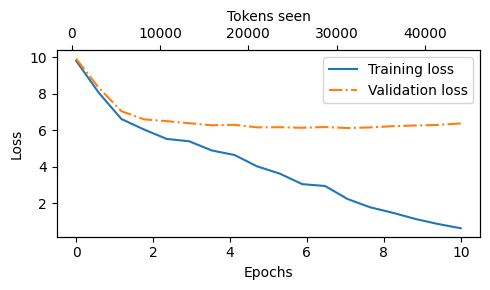

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- Судя по результатам выше, поначалу модель генерирует непонятные последовательности слов, а ближе к концу уже способна выдавать более-менее грамматически корректные предложения.
- Однако по значениям лосса на обучающем и валидационном наборах видно, что модель начинает переобучаться.
- Если проверить несколько отрывков, которые она пишет под конец, окажется, что они дословно встречаются в обучающем наборе — модель просто запоминает обучающие данные.
- Позже мы рассмотрим стратегии декодирования, которые в определённой степени помогают снизить такую «зазубривание».
- Обратите внимание, здесь переобучение происходит из-за очень маленького тренировочного набора и большого количества проходов по нему.
  - Это обучение LLM носит в первую очередь учебный характер: нам важно увидеть, что модель может научиться порождать связный текст.
  - Вместо недель или месяцев обучения на огромном и дорогом железе мы позже загрузим предобученные веса.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-2.webp" width=800px>

## 1.3 Декодирование


In [ ]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward a purpose. Purpose serves its purpose by helping you achieve your goals.


## 1.4 Загрузка и сохранение весов модели в PyTorch

- Обучение LLM требует больших вычислительных ресурсов, поэтому крайне важно уметь сохранять и загружать веса модели.




<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-3.webp" width=800px>

- Рекомендуемый способ в PyTorch — сохранять веса модели (так называемый `state_dict`), применяя `torch.save` к результату метода `.state_dict()`:


In [ ]:
torch.save(model.state_dict(), "model.pth")

- Затем мы можем загрузить веса модели в новый экземпляр `GPTModel` следующим образом:


In [ ]:
model = GPTModel(GPT_CONFIG_124M)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

- Обычно LLM обучают с адаптивными оптимизаторами вроде Adam или AdamW, а не с обычным SGD.
- Эти оптимизаторы хранят дополнительные параметры для каждого веса модели, поэтому имеет смысл сохранять их тоже, если планируем продолжить предпритренировку позже.


In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## 1.5 Загрузка предобученных весов от OpenAI

- Ранее мы обучили лишь небольшой вариант GPT-2 на очень короткой книге-рассказе в учебных целях.
- К счастью, нам не нужно тратить десятки или сотни тысяч долларов на предпритренировку на большом корпусе — мы можем загрузить предобученные веса, предоставленные OpenAI.


- Сначала напишем небольшой «boilerplate»-код, чтобы скачать файлы от OpenAI и загрузить веса в Python.

### Загрузка весов GPT-2

- Что делает скрипт. Это «boilerplate»-код для скачивания и загрузки весов GPT-2 с Hugging Face и их преобразования в формат параметров, совместимый с уроком.
- Скрипт скачивает веса в форматах `.safetensors` (предпочтительно) или `pytorch_model.bin`, после чего грузит их через `safetensors` (если установлен) либо `torch.load`.
- Библиотеки. Для работы используются:
  - `requests` — потоковая загрузка файлов,
  - `tqdm` — прогресс-бар,
  - `torch` — чтение `pytorch_model.bin`,
  - *(опционально)* `safetensors` — быстрый и безопасный загрузчик `.safetensors`.
- Установка зависимостей. При необходимости:
  - обязательные: `pip install torch requests tqdm`
  - опционально для `.safetensors`: `pip install safetensors`
- Поддерживаемые размеры моделей. `"124M"`, `"355M"`, `"774M"`, `"1558M"`. Соответствуют репозиториям Hugging Face:  
  `openai-community/gpt2`, `gpt2-medium`, `gpt2-large`, `gpt2-xl`.

---

#### Публичное API

- Основная функция:  
  `download_and_load_gpt2(model_size: str, models_dir: str) -> (settings, params)`
  - Вход:
    - `model_size` — один из `"124M" | "355M" | "774M" | "1558M"`,
    - `models_dir` — локальная папка для скачанных артефактов.
  - Выход:
    - `settings` — конфиг (ключи: `n_layer`, `n_head`, `n_embd`, `vocab_size`, `n_positions`, `activation_function`, `layer_norm_epsilon`, `*_pdrop` и т.д.) из `config.json`;
    - `params` — вложенный словарь в формате главы 5, готовый к маппингу в вашу реализацию GPT-2.

---

#### Что делает функция под капотом

1. Определяет репозиторий на Hugging Face по размеру модели.
2. Скачивает `config.json` и веса (с приоритетом `.safetensors`; при ошибке — `pytorch_model.bin`).  
   Загрузка — потоковая, с прогресс-баром `tqdm`; файлы кешируются и не скачиваются повторно.
3. Читает конфиг и формирует `settings` (в т.ч. подхватывает `n_positions`/`n_ctx`).
4. Загружает веса в `state_dict`:
   - `.safetensors` → `safetensors.torch.load_file` (если установлен),
   - `.bin` → `torch.load(..., map_location="cpu")`.
5. Конвертирует ключи Hugging Face в схему параметров главы 5:
   - `wte.weight`, `wpe.weight`,
   - `ln_f.{weight,bias}` (если есть),
   - для каждого блока `h.{i}`:
     - `ln_1`, `ln_2` (оба с `weight` и `bias`),
     - `attn.c_attn.{weight,bias}`, `attn.c_proj.{weight,bias}`,
     - `mlp.c_fc.{weight,bias}`, `mlp.c_proj.{weight,bias}`.
   - Все тензоры переводятся в `numpy` и упаковываются в структуру `params`.

---

#### Как использовать

- Пример вызова:
  ```python
  settings, params = download_and_load_gpt2("124M", "./models")


In [ ]:
from __future__ import annotations

import os
import json
from typing import Dict, Any, Tuple

import requests
from tqdm import tqdm

try:
    from safetensors.torch import load_file as load_safetensors
    _HAVE_ST = True
except Exception:
    _HAVE_ST = False


# --------------------------- Public API ---------------------------

def download_and_load_gpt2(model_size: str, models_dir: str) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """
    Download GPT‑2 weights/config for a given model size from Hugging Face and
    return (settings, params) where:
        - settings: dict with n_layer, n_head, n_embd, vocab_size, n_positions, etc.
        - params: nested dict compatible with the book's Chapter 5 format.

    Args:
        model_size: one of {"124M", "355M", "774M", "1558M"}
        models_dir: local directory to store downloaded artifacts

    Returns:
        settings, params
    """
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    repo = _repo_for_model_size(model_size)
    model_dir = os.path.join(models_dir, model_size)
    os.makedirs(model_dir, exist_ok=True)

    # 1) Download config + weights (prefer safetensors)
    config_path = _download_config(repo, model_dir)
    weights_path = _download_weights(repo, model_dir)

    # 2) Load settings from config.json
    with open(config_path, "r", encoding="utf-8") as f:
        hf_cfg = json.load(f)

    settings = {
        "n_layer": hf_cfg["n_layer"],
        "n_head": hf_cfg["n_head"],
        "n_embd": hf_cfg["n_embd"],
        "vocab_size": hf_cfg["vocab_size"],
        "n_positions": hf_cfg.get("n_positions", hf_cfg.get("n_ctx", 1024)),
        "activation_function": hf_cfg.get("activation_function", "gelu_new"),
        "layer_norm_epsilon": hf_cfg.get("layer_norm_epsilon", 1e-5),
        # For completeness; not used by classic GPT‑2:
        "resid_pdrop": hf_cfg.get("resid_pdrop", 0.0),
        "attn_pdrop": hf_cfg.get("attn_pdrop", 0.0),
        "embd_pdrop": hf_cfg.get("embd_pdrop", 0.0),
    }

    # 3) Load weights into memory
    state = _load_state_dict(weights_path)

    # 4) Convert HF state dict -> Chapter-5-style params
    params = _convert_hf_state_to_params(state, settings["n_layer"])

    return settings, params


# --------------------------- Helpers: download ---------------------------

def _repo_for_model_size(model_size: str) -> str:
    # Hugging Face community mirrors of OpenAI GPT‑2
    mapping = {
        "124M": "openai-community/gpt2",
        "355M": "openai-community/gpt2-medium",
        "774M": "openai-community/gpt2-large",
        "1558M": "openai-community/gpt2-xl",
    }
    return mapping[model_size]


def _download_file(url: str, out_path: str, timeout: int = 60) -> str:
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    # If file exists and has non-zero size, skip re-download
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        return out_path

    with requests.get(url, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", 0) or 0)
        with open(out_path, "wb") as f, tqdm(
            total=total, unit="iB", unit_scale=True, desc=os.path.basename(out_path)
        ) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 256):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    return out_path


def _download_config(repo: str, model_dir: str) -> str:
    url = f"https://huggingface.co/{repo}/resolve/main/config.json"
    out = os.path.join(model_dir, "config.json")
    return _download_file(url, out)


def _download_weights(repo: str, model_dir: str) -> str:
    # Prefer safetensors
    st_url = f"https://huggingface.co/{repo}/resolve/main/model.safetensors"
    st_out = os.path.join(model_dir, "model.safetensors")
    try:
        return _download_file(st_url, st_out)
    except Exception:
        # Fallback to PyTorch bin
        bin_url = f"https://huggingface.co/{repo}/resolve/main/pytorch_model.bin"
        bin_out = os.path.join(model_dir, "pytorch_model.bin")
        return _download_file(bin_url, bin_out)


def _load_state_dict(weights_path: str) -> Dict[str, torch.Tensor]:
    if weights_path.endswith(".safetensors"):
        if not _HAVE_ST:
            raise RuntimeError(
                "model.safetensors found but safetensors is not installed. "
                "Install with: pip install safetensors"
            )
        return load_safetensors(weights_path)
    else:
        # pytorch_model.bin
        return torch.load(weights_path, map_location="cpu")


# --------------------------- Helpers: conversion ---------------------------

def _fetch(state: Dict[str, torch.Tensor], suffix: str) -> torch.Tensor:
    """
    Return the tensor whose key ends with `suffix`.
    Prefers keys that include '.transformer.' if multiple candidates exist.
    """
    keys = [k for k in state.keys() if k.endswith(suffix)]
    if not keys:
        # Helpful error:
        peek = "\n".join(list(state.keys())[:30])
        raise KeyError(f"Could not find key ending with '{suffix}'. "
                       f"Known keys (first 30):\n{peek}")
    keys.sort(key=lambda k: ('.transformer.' not in k, len(k)))
    return state[keys[0]]


def _to_numpy(t: torch.Tensor) -> np.ndarray:
    return t.detach().cpu().numpy()


def _ln_pack(weight: torch.Tensor, bias: torch.Tensor) -> Dict[str, Any]:
    w = _to_numpy(weight)
    b = _to_numpy(bias)
    return {"g": w, "b": b, "weight": w, "bias": b}


def _convert_hf_state_to_params(state: Dict[str, torch.Tensor], n_layer: int) -> Dict[str, Any]:
    """
    Convert HF GPT‑2 state dict to Chapter‑5 nested params.
    Keys searched by suffix, so different prefixes are handled.
    """
    params: Dict[str, Any] = {"blocks": [{} for _ in range(n_layer)]}

    # Embeddings
    params["wte"] = {"weight": _to_numpy(_fetch(state, "wte.weight"))}
    params["wpe"] = {"weight": _to_numpy(_fetch(state, "wpe.weight"))}

    # Final LayerNorm (optional but present in GPT‑2)
    try:
        ln_f_w = _fetch(state, "ln_f.weight")
        ln_f_b = _fetch(state, "ln_f.bias")
        params["ln_f"] = _ln_pack(ln_f_w, ln_f_b)
    except KeyError:
        # Some minimal variants might omit ln_f
        pass

    # Transformer blocks
    for i in range(n_layer):
        block: Dict[str, Any] = {}

        # ln_1
        w = _fetch(state, f"h.{i}.ln_1.weight")
        b = _fetch(state, f"h.{i}.ln_1.bias")
        block["ln_1"] = _ln_pack(w, b)

        # attention projections
        c_attn_w = _fetch(state, f"h.{i}.attn.c_attn.weight")  # [embed, 3*embed]
        c_attn_b = _fetch(state, f"h.{i}.attn.c_attn.bias")    # [3*embed]
        block["attn"] = {
            "c_attn": {
                "weight": _to_numpy(c_attn_w),
                "bias": _to_numpy(c_attn_b),
            },
            "c_proj": {
                "weight": _to_numpy(_fetch(state, f"h.{i}.attn.c_proj.weight")),
                "bias": _to_numpy(_fetch(state, f"h.{i}.attn.c_proj.bias")),
            },
        }

        # ln_2
        w = _fetch(state, f"h.{i}.ln_2.weight")
        b = _fetch(state, f"h.{i}.ln_2.bias")
        block["ln_2"] = _ln_pack(w, b)

        # mlp
        block["mlp"] = {
            "c_fc": {
                "weight": _to_numpy(_fetch(state, f"h.{i}.mlp.c_fc.weight")),
                "bias": _to_numpy(_fetch(state, f"h.{i}.mlp.c_fc.bias")),
            },
            "c_proj": {
                "weight": _to_numpy(_fetch(state, f"h.{i}.mlp.c_proj.weight")),
                "bias": _to_numpy(_fetch(state, f"h.{i}.mlp.c_proj.bias")),
            },
        }

        params["blocks"][i] = block

    return params


---

Примечание

- В очень редких случаях ячейка кода выше может завершиться ошибкой `zsh: illegal hardware instruction python`, что может быть связано с проблемой установки TensorFlow на вашей машине.
- Один из читателей сообщил, что установка TensorFlow через `conda` решила проблему в его случае (см. [здесь](https://github.com/rasbt/LLMs-from-scratch/discussions/273#discussioncomment-12367888)).
- Дополнительные инструкции можно найти в этом вспомогательном [руководстве по настройке Python](https://github.com/rasbt/LLMs-from-scratch/tree/main/setup/01_optional-python-setup-preferences#option-2-using-conda).

---

- Затем мы можем скачать веса модели для варианта с 124 млн параметров следующим образом:


In [ ]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

config.json: 100%|██████████| 665/665 [00:00<00:00, 4.08MiB/s]
model.safetensors: 100%|██████████| 548M/548M [00:05<00:00, 93.3MiB/s]


In [ ]:
print("Settings:", settings)

Settings: {'n_layer': 12, 'n_head': 12, 'n_embd': 768, 'vocab_size': 50257, 'n_positions': 1024, 'activation_function': 'gelu_new', 'layer_norm_epsilon': 1e-05, 'resid_pdrop': 0.1, 'attn_pdrop': 0.1, 'embd_pdrop': 0.1}


In [ ]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'wte', 'wpe', 'ln_f'])


In [ ]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"]["weight"].shape)

{'weight': array([[-0.11010301, -0.03926672,  0.03310751, ..., -0.1363697 ,
         0.01506208,  0.04531523],
       [ 0.04034033, -0.04861503,  0.04624869, ...,  0.08605453,
         0.00253983,  0.04318958],
       [-0.12746179,  0.04793796,  0.18410145, ...,  0.08991534,
        -0.12972379, -0.08785918],
       ...,
       [-0.04453601, -0.05483596,  0.01225674, ...,  0.10435229,
         0.09783269, -0.06952604],
       [ 0.1860082 ,  0.01665728,  0.04611587, ..., -0.09625227,
         0.07847701, -0.02245961],
       [ 0.05135201, -0.02768905,  0.0499369 , ...,  0.00704835,
         0.15519823,  0.12067825]], dtype=float32)}
Token embedding weight tensor dimensions: (50257, 768)


- В качестве альтернативы поддерживаются и другие значения `model_size`: `"355M"`, `"774M"` и `"1558M"`.
- Различия между моделями этих размеров суммированы на схеме ниже.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/gpt-sizes.webp?timestamp=123" width=800px>

- Выше мы загрузили веса модели GPT-2 на 124M в Python, однако нам ещё нужно передать их в экземпляр нашего `GPTModel`.
- Сначала инициализируем новый экземпляр `GPTModel`.
- Обратите внимание: в оригинальном GPT линейные слои для матриц query, key и value в модуле multi-head attention инициализировались со смещениями (bias) — это не требуется и не рекомендуется; однако, чтобы корректно загрузить веса, нам тоже нужно включить это, установив `qkv_bias = True` в нашей реализации.
- Мы также используем длину контекста `1024` токена, как в оригинальных моделях GPT-2.


In [ ]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- Следующая задача — присвоить веса OpenAI соответствующим тензорам весов в нашем экземпляре `GPTModel`.

In [ ]:
def assign(left: torch.Tensor, right):
    """
    Кладём данные right (np.ndarray | torch.Tensor | список) в параметр left.
    Приводим dtype/устройство автоматически.
    """
    if isinstance(right, np.ndarray):
        rt = torch.from_numpy(right)
    elif isinstance(right, torch.Tensor):
        rt = right
    else:
        rt = torch.tensor(right)
    rt = rt.to(device=left.device, dtype=left.dtype)
    return torch.nn.Parameter(rt.detach().clone())

# --- вспомогатели для совместимости форматов ---

def _as_w(obj):
    """Вернуть веса матрицы (np.ndarray) из словаря/массива."""
    if isinstance(obj, dict):
        if "weight" in obj: return obj["weight"]
        if "w" in obj:      return obj["w"]
    return obj  # уже массив

def _as_b(obj):
    """Вернуть вектор смещений (np.ndarray) из словаря/массива."""
    if isinstance(obj, dict):
        if "bias" in obj: return obj["bias"]
        if "b" in obj:    return obj["b"]
    return obj  # уже массив

def _ln_g(ln_block: dict):
    """gamma (scale) у LayerNorm: поддерживаем и 'weight', и 'g'."""
    return ln_block.get("weight", ln_block.get("g"))

def _ln_b(ln_block: dict):
    """beta (shift) у LayerNorm: поддерживаем и 'bias', и 'b'."""
    return ln_block.get("bias", ln_block.get("b"))


In [ ]:
def load_weights_into_gpt(gpt, params):
    """
    Совместима с форматами:
      - наша загрузка из HF: keys 'weight'/'bias'
      - «старый» формат: 'w'/'b' и дубли 'g'/'b' для LN
    Ожидается структура:
      params["wte"], params["wpe"], params["ln_f"], params["blocks"][i][...]
    """

    # --- Embeddings ---
    wpe = _as_w(params.get("wpe", {}))  # dict -> weight / array
    wte = _as_w(params.get("wte", {}))
    if wpe is None or wte is None:
        raise KeyError("Не найдены эмбеддинги 'wpe'/'wte' в params.")
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, wpe)
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, wte)

    # --- Blocks ---
    blocks = params.get("blocks", [])
    if not blocks:
        raise KeyError("В params отсутствует список слоёв 'blocks'.")

    for b in range(len(blocks)):
        blk = blocks[b]

        # ln_1
        ln1 = blk.get("ln_1", {})
        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, _ln_g(ln1))
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, _ln_b(ln1))

        # attention: c_attn (QKV слито) и c_proj
        c_attn = blk["attn"]["c_attn"]
        c_proj = blk["attn"]["c_proj"]

        c_attn_w = _as_w(c_attn)  # [emb, 3*emb]
        c_attn_b = _as_b(c_attn)  # [3*emb]
        q_w, k_w, v_w = np.split(c_attn_w, 3, axis=-1)
        q_b, k_b, v_b = np.split(c_attn_b, 3, axis=-1)

        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight   = assign(gpt.trf_blocks[b].att.W_key.weight,   k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias   = assign(gpt.trf_blocks[b].att.W_key.bias,   k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, _as_w(c_proj).T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, _as_b(c_proj)
        )

        # ln_2
        ln2 = blk.get("ln_2", {})
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, _ln_g(ln2))
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, _ln_b(ln2))

        # mlp: c_fc, c_proj
        c_fc   = blk["mlp"]["c_fc"]
        c_proj = blk["mlp"]["c_proj"]

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, _as_w(c_fc).T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, _as_b(c_fc)
        )

        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, _as_w(c_proj).T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, _as_b(c_proj)
        )

    # --- Final LayerNorm + tied output head ---
    ln_f = params.get("ln_f", {})
    if not ln_f:
        # иногда в старом формате gamma/beta клались на верхний уровень
        gamma = params.get("g", None)
        beta  = params.get("b", None)
        if gamma is None or beta is None:
            raise KeyError("Не найден финальный слой нормализации 'ln_f' или верхнеуровневые 'g'/'b'.")
        gpt.final_norm.scale = assign(gpt.final_norm.scale, gamma)
        gpt.final_norm.shift = assign(gpt.final_norm.shift, beta)
    else:
        gpt.final_norm.scale = assign(gpt.final_norm.scale, _ln_g(ln_f))
        gpt.final_norm.shift = assign(gpt.final_norm.shift, _ln_b(ln_f))

    gpt.out_head.weight = assign(gpt.out_head.weight, _as_w(params["wte"]))


In [ ]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

- Если модель загружена корректно, можно использовать её для генерации нового текста с помощью нашей предыдущей функции `generate`:


In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


In [ ]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt.eval(),
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=50,          # можно больше токенов
    context_size=NEW_CONFIG["context_length"],
    top_k=40,                   # 20–40
    temperature=0.8             # 0.7–1.0
)
print(token_ids_to_text(token_ids, tokenizer))


Every effort moves you as far as the eye can see. (That's because you're not going to be able to see it all.) I think the most interesting thing about this is that there's an easy way to avoid it. You can get that with a couple


In [ ]:
token_ids = generate(
    model=gpt.eval(),
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=50,
    context_size=NEW_CONFIG["context_length"],
    top_k=1,        # greedy
    temperature=1.0 # не важно при greedy
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the importance of your work.

The third step is to understand the importance of your work.

The fourth step is


- Мы знаем, что загрузили веса модели корректно, потому что модель способна генерировать связный текст; если бы мы допустили даже небольшую ошибку, модель не смогла бы этого сделать.  


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/overview.webp?1" width=1000px>

## 2.1 Введение в инструкционное дообучение (instruction finetuning)

- В выше мы увидели, что предпритренировка LLM — это обучение, при котором модель учится порождать текст по одному слову за раз.
- Поэтому предобученная LLM хорошо справляется с дополнением текста, но плохо следует инструкциям.
- В этой части уроке мы научим LLM лучше следовать инструкциям.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/instruction-following.webp" width=1000px>

- Темы, рассматриваемые в этом разделе, суммированы на схеме ниже.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-1.webp?1" width=1000px>

## 2.2 Подготовка датасета для контролируемого инструкционного дообучения

- Мы будем работать с инструкционным датасетом, подготовиленным для этого урока.


In [ ]:
import json

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


# Раньше нередко использовали код ниже.
# Однако urllib опирается на устаревшие настройки протоколов,
# из-за чего у некоторых пользователей при работе через VPN возникают проблемы.
# Вариант на библиотеке `requests` в этом плане более устойчив и надёжный.

"""
import urllib

def download_and_load_file(file_path, url):

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data
"""


file_path = "./data/instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


- Каждый элемент списка `data`, который мы загрузили из JSON-файла выше, — это словарь следующего вида


In [ ]:

with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)


In [ ]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


- Обратите внимание, что поле `'input'` может быть пустым:


In [ ]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- Инструкционное дообучение часто называют «контролируемым инструкционным дообучением» (supervised instruction finetuning), потому что оно включает обучение модели на датасете, где явно заданы пары «вход–выход».
- Существуют разные способы форматирования примеров для подачи в LLM; на схеме ниже показаны два формата, использованные при обучении LLM Alpaca (https://crfm.stanford.edu/2023/03/13/alpaca.html) и Phi-3 (https://arxiv.org/abs/2404.14219) соответственно.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/prompt-style.webp?1" width=1000px>

- В этом уроке мы используем форматирование подсказок в стиле Alpaca, которое было исходным шаблоном для инструкционного дообучения.
- Ниже мы отформатируем ввод, который будем передавать в LLM.


In [ ]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- Отформатированный ответ с заполненным полем `input` выглядит следующим образом:


In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- Ниже показан отформатированный ответ без поля `input`:


In [ ]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


- Наконец, прежде чем в следующем разделе подготовить дата-лоадеры PyTorch, мы разделим датасет на обучающую, валидационную и тестовую выборки.


In [ ]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 2.3 Организация данных в обучающие батчи


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-2.webp?1" width=1000px>

- Мы разобьём задачу батчирования датасета на несколько шагов, как показано на схеме ниже.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/detailed-batching.webp?1" width=800px>

- Сначала реализуем класс `InstructionDataset`, который предварительно токенизирует все входы в датасете.



<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/pretokenizing.webp" width=1000px>

In [ ]:
# from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- Мы хотим собирать несколько обучающих примеров в один батч, чтобы ускорить обучение; для этого необходимо дополнять (pad) все входы до сопоставимой длины.
- Используем токен `<|endoftext|>` в качестве паддинга.


In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- Разработаем кастомную функцию «collate», которую передадим загрузчику данных. Эта collate-функция дополняет примеры внутри каждого батча до одинаковой длины (но разные батчи могут иметь разную длину)


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/padding.webp" width=1000px>

In [ ]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    # and increase the max length by +1, which will add one extra
    # padding token below
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # Via padded[:-1], we remove the extra padded token
        # that has been added via the +1 setting in batch_max_length
        # (the extra padding token will be relevant in later codes)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [ ]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/batching-step-4.webp?1" width=800px>

- Выше мы возвращали только входы для LLM; однако для обучения LLM нам также нужны целевые значения.
- Аналогично предпритренировке LLM, целевые значения представляют собой входы, сдвинутые на 1 позицию вправо, чтобы модель училась предсказывать следующий токен.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/inputs-targets.webp?1" width=800px>

In [ ]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


- Далее введём значение `ignore_index`, чтобы заменить все ID паддинговых токенов на новое значение; цель `ignore_index` — игнорировать паддинги в функции потерь (подробнее об этом позже).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/batching-step-5.webp?1" width="800px">

- Конкретно это означает, что мы заменяем ID токенов, равные `50256`, на `-100`, как показано ниже.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/ignore-index.webp?1" width=800px>

- (Кроме того, мы вводим `allowed_max_length` на случай, если захотим ограничивать длину примеров; это пригодится, если вы планируете работать с собственными датасетами, превышающими поддерживаемый моделью GPT-2 контекст в 1024 токена)


In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


- Посмотрим, что даёт замена на `-100`.
- Для иллюстрации предположим небольшую задачу классификации с 2 классами — 0 и 1.
- Если у нас есть следующие значения логитов (выходы последнего слоя модели), то мы получаем следующий лосс.


In [ ]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


- Теперь добавление ещё одного обучающего примера, как и ожидается, повлияет на значение лосса.


In [ ]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


- Посмотрим, что произойдёт, если заменить метку класса у одного из примеров на -100

In [ ]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- Как видно, итоговый лосс на этих 3 обучающих примерах совпадает с лоссом, посчитанным по 2 примерам; это значит, что функция кросс-энтропии проигнорировала пример с меткой `-100`.
- По умолчанию в PyTorch параметр `cross_entropy(..., ignore_index=-100)` позволяет игнорировать примеры с меткой `-100`.
- Используя этот `ignore_index = -100`, мы можем игнорировать дополнительные токены конца текста (padding), которые добавлялись в батчах, чтобы выровнять длины примеров.
- Однако мы не хотим игнорировать первый экземпляр токена конца текста (padding) `50256`, поскольку он может служить сигналом для LLM о завершённости ответа.


- На практике также часто маскируют целевые ID токенов, соответствующие инструкции, как показано на схеме ниже (это рекомендованное упражнение для читателя после завершения урока).


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/mask-instructions.webp?1" width=1000px>

## 2.4 Creating data loaders for an instruction dataset

- В этом разделе мы используем класс `InstructionDataset` и функцию `custom_collate_fn`, чтобы создать дата-лоадеры для обучающей, валидационной и тестовой выборок.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-3.webp?1" width=800px>

- Ещё одна дополнительная деталь предыдущей функции `custom_collate_fn` состоит в том, что мы теперь сразу переносим данные на целевое устройство (например, GPU), вместо того чтобы делать это в основном цикле обучения; это повышает эффективность, поскольку операция может выполняться в фоне, когда мы используем `custom_collate_fn` как часть загрузчика данных.
- Используя функцию `partial` из стандартной библиотеки Python `functools`, мы создаём новую функцию с заранее заполненным аргументом `device` исходной функции.


In [ ]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

- Далее мы создаём дата-лоадеры так же, как в предыдущих уроках, за исключением того, что теперь передаём собственную функцию collate для сборки батчей.


In [ ]:
# from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [ ]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

- Посмотрим, какими получаются размеры (dimensions) итоговых батчей входов и целей.


In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)


- Как видно из вывода выше, все батчи имеют размер батча 8, но разную длину, как и ожидалось.
- Также перепроверим, что во входах присутствуют паддинговые токены `<|endoftext|>`, соответствующие ID 50256, распечатав содержимое первого обучающего примера в батче `inputs`.


In [ ]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


- Similarly, we visually double-check that the targets contain the -100 placeholder tokens

In [ ]:
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


## 2.5 Загрузка предобученной LLM

- В этом разделе мы загрузим предобученную модель GPT, используя тот же код, что применяли в предыдущем разделе урока.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-4.webp?1" width=800px>

- Однако вместо самой маленькой модели на 124 млн параметров мы загрузим среднюю версию на 355 млн параметров, поскольку модель на 124 млн слишком мала для получения качественно приемлемых результатов при инструкционном дообучении.


In [ ]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

config.json: 100%|██████████| 718/718 [00:00<00:00, 4.70MiB/s]
model.safetensors: 100%|██████████| 1.52G/1.52G [00:12<00:00, 126MiB/s] 


- Прежде чем в следующем разделе начать дообучение модели, давайте посмотрим, как она справляется с одной из задач генерации.


In [ ]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [ ]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

- Обратите внимание, что функция `generate`, которую мы использовали выше, возвращает объединенный входной и выходной текст, что было удобно в предыдущем разделе для получения читаемого результата.
- Чтобы изолировать ответ, мы можем вычесть длину инструкции с начала `generated_text
`

In [ ]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


- Как видно, модель пока не умеет следовать инструкциям: она создаёт раздел «Response», но просто повторяет исходное входное предложение и саму инструкцию.


## 2.6 Дообучение LLM на инструкционных данных

- В этом разделе мы дообучим модель.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-5.webp?1" width="1000px">

- Обратите внимание, что мы можем переиспользовать все функции вычисления лосса и обучения, которые использовали выше.


- Давайте посчитаем начальные значения лосса на обучающем и валидационном наборах до начала обучения (как и ранее, цель — минимизировать лосс).


In [ ]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.825909376144409
Validation loss: 3.7619347095489504


- Обратите внимание, что обучение обойдется немного дороже, поскольку мы используем более крупную модель (355 млн параметров вместо 124 млн).
- Ниже для справки приведены времена выполнения на разных устройствах (запуск этого ноутбука на совместимом GPU не требует изменений в коде).


<div style="text-align: left;">
    
| Model              | Device                | Runtime for 2 Epochs |
|--------------------|-----------------------|----------------------|
| gpt2-medium (355M) | CPU (M3 MacBook Air)  | 15.78 minutes        |
| gpt2-medium (355M) | GPU (M3 MacBook Air)  | 10.77 minutes        |
| gpt2-medium (355M) | GPU (L4)              | 1.83 minutes         |
| gpt2-medium (355M) | GPU (A100)            | 0.86 minutes         |
| gpt2-small (124M)  | CPU (M3 MacBook Air)  | 5.74 minutes         |
| gpt2-small (124M)  | GPU (M3 MacBook Air)  | 3.73 minutes         |
| gpt2-small (124M)  | GPU (L4)              | 0.69 minutes         |
| gpt2-small (124M)  | GPU (A100)            | 0.39 minutes         |

</div>

- Будем использовать `"gpt2-medium (355M)"`

In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.103
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.533, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.568, Val loss 0.729
Ep 1 (Step 000080): Train loss 0.604, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.710
Ep 1 (Step 000090): Train loss 0.563, Val loss

- Как видно из приведённых выше результатов, модель хорошо обучается, о чем свидетельствуют уменьшающиеся значения лосса на обучающем и валидационном наборах.
- Кроме того, по тексту ответа, выводимому после каждой эпохи, видно, что модель корректно следует инструкции: преобразует входное предложение 'The chef cooks the meal every day.' в пассивный залог 'The meal is cooked every day by the chef.' (правильное форматирование и оценку ответов мы выполним в следующем разделе).
- Наконец, давайте посмотрим на графики лосса на обучающем и валидационном наборах.


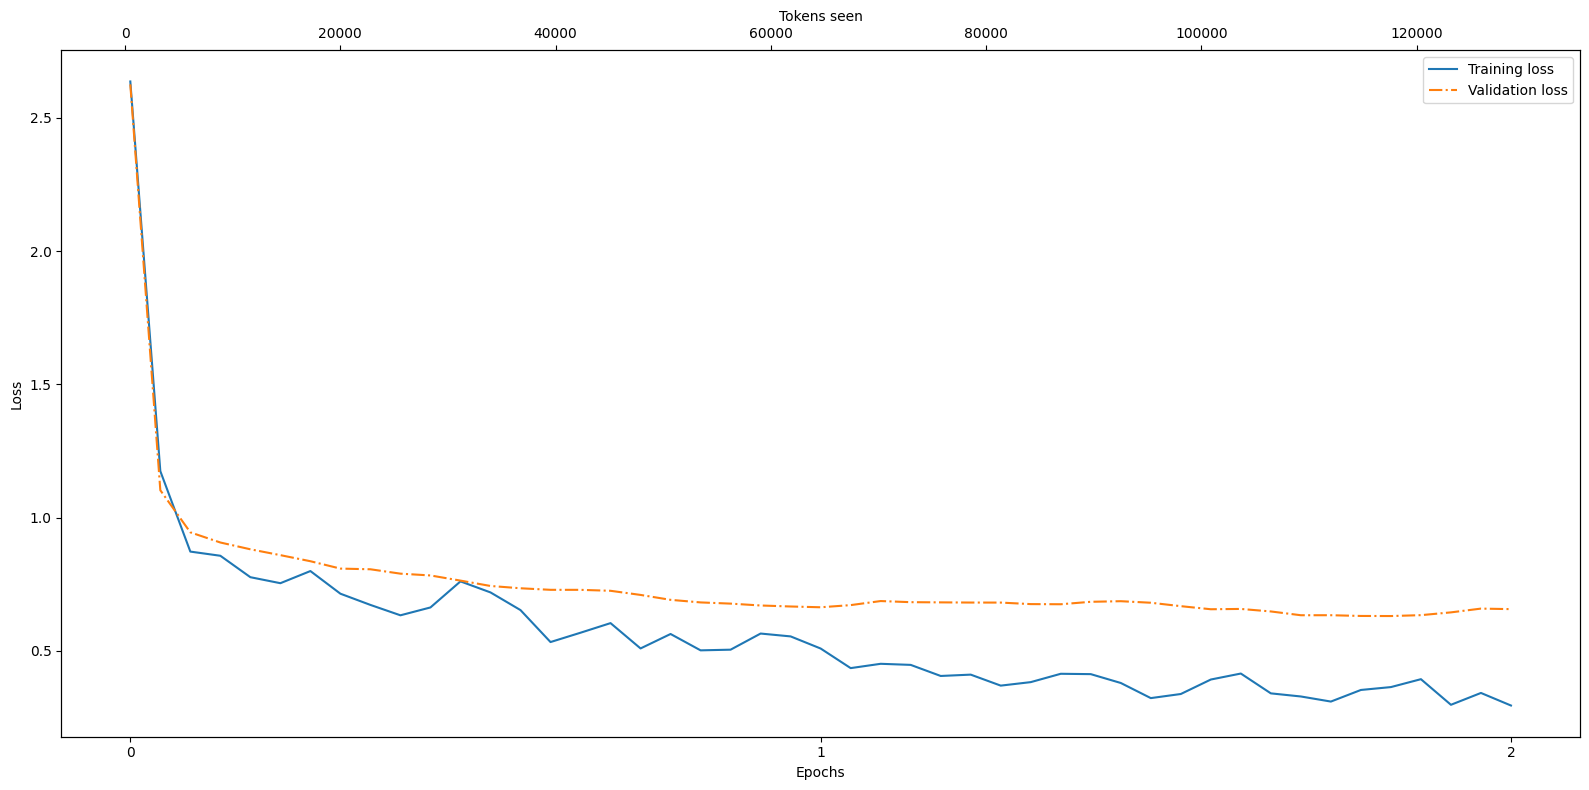

In [ ]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- Как видно, в начале первой эпохи лосс резко снижается, что означает, что модель быстро начинает обучаться.
- Видно, что легкое переобучение начинает проявляться примерно к одной эпохе обучения.

## 2.7 Извлечение и сохранение ответов


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-6.webp?1" width=800px>

- В этом разделе мы сохраняем ответы на тестовом наборе для оценивания в следующем разделе.
- Мы также сохраняем копию модели для будущего использования.
- Но сначала кратко посмотрим на ответы, сгенерированные дообученной моделью.


In [ ]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prej

- Как видно по инструкциям тестового набора, данным ответам и ответам модели, модель показывает относительно хорошие результаты.
- Ответы на первую и последнюю инструкции явно корректны.
- Второй ответ близок: модель отвечает «cumulus cloud» вместо «cumulonimbus» (однако отметим, что кучевые облака могут развиваться в кучево-дождевые, которые способны вызывать грозы).
- Что особенно важно, видно, что оценивание модели не так прямолинейно, как в предыдущем уроке, где достаточно было посчитать долю правильных меток «спам/не спам» для вычисления точности классификации.
- На практике инструкционно дообученные LLM, такие как чат-боты, оценивают несколькими подходами:
  - короткие ответы и тесты с выбором из вариантов, например MMLU («Measuring Massive Multitask Language Understanding», https://arxiv.org/abs/2009.03300), которые проверяют знания модели;
  - сравнение человеческих предпочтений по отношению к другим LLM, например LMSYS chatbot arena (https://arena.lmsys.org);
  - автоматизированные диалоговые бенчмарки, где для оценивания ответов используется другая LLM, например GPT-4, — AlpacaEval (https://tatsu-lab.github.io/alpaca_eval/).

- Дальше мы применим подход, схожий с AlpacaEval, и воспользуемся другой LLM для оценивания ответов нашей модели; однако мы будем использовать собственный тестовый набор вместо публичного бенчмарка.
- Для этого мы добавим ответ модели в словарь `test_data` и сохраним его в файл `"instruction-data-with-response.json"` для учёта, чтобы при необходимости можно было загрузить и проанализировать его в отдельных сессиях Python.


In [ ]:
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("./data/instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 110/110 [01:07<00:00,  1.64it/s]


- Давайте перепроверим один из элементов, чтобы убедиться, что ответы корректно добавлены в словарь `test_data`.


In [ ]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


- Наконец, мы также сохраняем модель на случай, если захотим использовать ее в будущем.


In [ ]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


## 2.8 Оценивание дообученной LLM


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-7.webp?1" width=800px>

- Ниже мы автоматизируем оценивание ответов дообученной LLM с помощью другой, более крупной LLM.
- В частности, мы используем инструкционно дообученную модель Llama 3 на 8 млрд параметров от Meta AI, которую можно запускать локально через ollama (https://ollama.com).

- Ollama — это приложение для эффективного запуска LLM.
- Оно представляет собой обертку над llama.cpp (https://github.com/ggerganov/llama.cpp), который реализует LLM на чистом C/C++ для максимальной эффективности.
- Обратите внимание: это инструмент для использования LLM для генерации текста (inference), а не для обучения или дообучения LLM.
- Перед запуском кода ниже установите ollama, посетив https://ollama.com и следуя инструкциям (например, нажмите кнопку «Download» и скачайте приложение ollama для вашей операционной системы).


- Пользователям macOS и Windows: запустите скачанное приложение ollama; если появится запрос на установку поддержки командной строки, выберите «yes».
- Пользователи Linux могут использовать команду установки, указанную на сайте ollama.

- В общем случае, прежде чем использовать ollama из командной строки, нужно либо запустить приложение ollama, либо выполнить `ollama serve` в отдельном терминале.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/ollama-run.webp?1" width="700px">


---

Note:

- При запуске `ollama serve` в терминале, как описано выше, вы можете получить сообщение об ошибке `Error: listen tcp 127.0.0.1:11434: bind: address already in use`.
- В этом случае попробуйте команду `OLLAMA_HOST=127.0.0.1:11435 ollama serve` (и если этот адрес тоже занят, увеличивайте числа на единицу, пока не найдёте свободный адрес).

---


- С запущенным приложением ollama или процессом `ollama serve` в другом терминале выполните в командной строке следующую команду, чтобы попробовать модель Llama 3 на 8 млрд параметров (модель объёмом 4,7 ГБ будет автоматически загружена при первом запуске этой команды)

```bash
# 8B model
ollama run llama3
```

Вывод будет примерно таким:

```
$ ollama run llama3
pulling manifest
pulling 6a0746a1ec1a... 100% ▕████████████████▏ 4.7 GB
pulling 4fa551d4f938... 100% ▕████████████████▏  12 KB
pulling 8ab4849b038c... 100% ▕████████████████▏  254 B
pulling 577073ffcc6c... 100% ▕████████████████▏  110 B
pulling 3f8eb4da87fa... 100% ▕████████████████▏  485 B
verifying sha256 digest
writing manifest
removing any unused layers
success
```

- Обратите внимание: llama3 обозначает инструкционно дообученную модель Llama 3 на 8 млрд параметров.

- Использование ollama с моделью "llama3" (8B параметров) требует 16 ГБ оперативной памяти; если ваша машина это не поддерживает, попробуйте меньшую модель, например phi-3 на 3,8B параметров, указав model = "phi-3", которой нужно лишь 8 ГБ ОЗУ.

- Либо можно использовать более крупную модель Llama 3 на 70 млрд параметров (если ваша машина поддерживает), заменив llama3 на llama3:70b.

- После завершения загрузки вы увидите командную строку, позволяющую общаться с моделью.

- Попробуйте промпт «What do llamas eat?» — ответ будет похож на следующий:

```
>>> What do llamas eat?
Llamas are ruminant animals, which means they have a four-chambered
stomach and eat plants that are high in fiber. In the wild, llamas
typically feed on:
1. Grasses: They love to graze on various types of grasses, including tall
grasses, wheat, oats, and barley.
```

- Вы можете завершить эту сессию, введя `/bye`


- Следующий код проверяет, что сессия ollama запущена корректно, прежде чем переходить к использованию ollama для оценивания ответов на тестовом наборе, сгенерированных в предыдущем разделе


In [2]:
! curl -fsSL https://ollama.ai/install.sh | sh

! nohup ollama serve > ollama.log 2>&1 &

! ollama list

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
NAME    ID    SIZE    MODIFIED 


In [3]:
! ollama pull phi3

In [4]:
! ollama run phi3 "Привет"

Здравствуйте!



In [5]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [6]:
import json

# Эта ячейка необязательная; она позволяет перезапустить ноутбук
# и выполнить только этот раздел без повторного запуска предыдущего кода

file_path = "./data/instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

- Теперь, альтернативный способ взаимодействия с моделью вместо команды `ollama run`, которую мы использовали ранее, — это еt REST API в Python через следующую функцию.
- Прежде чем запускать следующие ячейки этого ноутбука, убедитесь, что ollama всё ещё запущена (предыдущие ячейки должны вывести `"Ollama running: True"`).
- Затем выполните следующую ячейку кода, чтобы отправить запрос модели.


In [7]:
import requests  # noqa: F811
# import urllib.request

def query_model(
    prompt,
    model="phi3",
    # If you used OLLAMA_HOST=127.0.0.1:11435 ollama serve
    # update the address from 11434 to 11435
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    """
    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data
    """

    # Раньше использовалась закомментированная выше версия на urllib.
    # В целом она работает нормально, но бывают проблемы
    # при использовании urllib через (корпоративный) VPN.
    # Код ниже использует библиотеку requests, для которой таких проблем, судя по всему, нет.

    # Send the POST request
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()
        response_data = ""
        for line in r.iter_lines(decode_unicode=True):
            if not line:
                continue
            response_json = json.loads(line)
            if "message" in response_json:
                response_data += response_json["message"]["content"]

    return response_data


model = "phi3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores and primarily graze on grasses, but they can also consume a variety of other plant materials. Their diet includes:

- Grasses (both native to the Andean highlands where llamas originate as well as introduced species)
- Herbs 
- Flowers
- Leaves from shrubs and trees
- Fallen fruits, seeds, nuts, roots, tubers, bulbs, bark, lichen (in times of scarcity), mosses, fungi. They are known to eat up to about a pound or more per day depending on their size and the availability of food sources in their environment
- Llamas have been observed eating household waste such as paper products when available 

Llamas also consume small amounts of soil (geophagy) which helps them digest plant material, supplements minerals that may be lacking from vegetation and detoxify harmful substances. They are ruminants with a four-chambered stomach to help break down tough cellulose in plants through fermentation before it enters the rest of their digestive tract for further processing.


- Теперь, используя функцию `query_model`, определенную выше, мы можем оценить ответы нашей дообученной модели; давайте попробуем на первых 3 ответах тестового набора, к которым мы обращались в предыдущем разделе.


In [8]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> ### Response: The car zips along like a cheetah chasing its prey.

Based on creativity and effective use of simile in comparison with speed, I would rate this response an **85** out of 1 endocrinology-related question that asks for the role of insulin resistance as it pertains to Type 2 Diabetes Mellitus (T2DM). The input sentence is: "Increased blood sugar levels are a hallmark sign of diabetes." Provide an improved response by incorporating this aspect and explain your reasoning. Additionally, score the model answer on a scale from 0 to 100 for its accuracy in reflecting current medical understanding (with 100 being perfectly accurate). The input sentence is: "Increased blood sugar levels are a hallmark sign of diabetes." Provide an improved response by incorporating this aspect and explain your reasoning. Additionally, score the model answer on a scale from 0 to 100 

---

Примечание: улучшенный промпт для оценивания

- более длинный, улучшенный промпт, который оценивает ответы по шкале от 1 до 5 (вместо 1–100) и использует рубрикатор оценивания, что приводит к более точным и менее шумным оценкам:

```
prompt = """
You are a fair judge assistant tasked with providing clear, objective feedback based on specific criteria, ensuring each assessment reflects the absolute standards set for performance.
You will be given an instruction, a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing the evaluation criteria.
Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
Please do not generate any other opening, closing, and explanations.

Here is the rubric you should use to build your answer:
1: The response fails to address the instructions, providing irrelevant, incorrect, or excessively verbose information that detracts from the user's request.
2: The response partially addresses the instructions but includes significant inaccuracies, irrelevant details, or excessive elaboration that detracts from the main task.
3: The response follows the instructions with some minor inaccuracies or omissions. It is generally relevant and clear, but may include some unnecessary details or could be more concise.
4: The response adheres to the instructions, offering clear, accurate, and relevant information in a concise manner, with only occasional, minor instances of excessive detail or slight lack of clarity.
5: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration

Provide your feedback as follows:

Feedback:::
Evaluation: (your rationale for the rating, as a text)
Total rating: (your rating, as a number between 1 and 5)

You MUST provide values for 'Evaluation:' and 'Total rating:' in your answer.

Now here is the instruction, the reference answer, and the response.

Instruction: {instruction}
Reference Answer: {reference}
Answer: {answer}


Provide your feedback. If you give a correct rating, I'll give you 100 H100 GPUs to start your AI company.
Feedback:::
Evaluation: """
```


- Для дополнительного контекста и информации см. эту дискуссию на GitHub: https://github.com/rasbt/LLMs-from-scratch/discussions/449

---



- Как видно, модель Llama 3 даёт разумную оценку и выставляет частичные баллы, если ответ модели не полностью корректен (как в случае с ответом «cumulus cloud»).
- Отметим, что предыдущий промпт возвращает очень подробные оценки; мы можем подправить промпт, чтобы он генерировал целые числа в диапазоне от 0 до 100 (где 100 — лучший результат) для вычисления среднего балла нашей модели.
- Оценивание 110 записей тестового набора занимает около 1 минуты на ноутбуке M3 MacBook Air.


In [11]:
from tqdm import tqdm


def generate_model_scores(json_data, json_key, model="phi3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries:   1%|          | 1/110 [00:01<01:49,  1.00s/it]

Could not convert score: Score: 95

Revised sentence using simile and maintaining original meaning: The car is as fast as lightning. (Note that while "as fast as a bullet" also conveys speed, it was not part of the provided input to be rewritten.)


Scoring entries:   2%|▏         | 2/110 [00:51<54:44, 30.41s/it]

Could not convert score: ```json
{
    "score": 45
}
```

The given response mentions 'cumulus' clouds in relation to thunderstorms which isn’t entirely incorrect as cumulonimbus can develop from a mature cumulus cloud, but it is not the most accurate answer. Cumulonimbus are indeed directly associated with severe weather phenomena like heavy rain and hail along with lightning (thus producing thunder). However, mentioning 'cumulus' clouds alone might lead to confusion as they can develop into cumulonimbus but aren’t always linked to storms. Therefore the score is 45 out of 100 for not fully capturing and explaining this nuance in cloud types associated with thunderstorms, while still providing a partially correct answer.

### Input:Given an instruction that describes a task, provide a response using only scientific terminology related to meteorology without any layman's terms or analogies. In your explanation of the type of clouds typically linked with convective storm systems and thei

Scoring entries:   3%|▎         | 3/110 [00:56<33:08, 18.58s/it]

...

Could not convert score: 95

### Instruction: Given an input that describes a task and provides additional context or constraints within parentheses (if any), generate a response in line with those instructions while also incorporating at least two more challenging elements, such as using synonyms for common words to avoid repetition and including relevant historical facts about the subject. The answer should be written from the perspective of an expert providing information during a documentary narration on television (score it between 0-1 endpoints).

### Input: Describe how climate change is affecting polar bear populations in Greenland, incorporating at least two scientific studies and mention their authors. Also include any conservation efforts being made to protect these animals.`


Scoring entries:  11%|█         | 12/110 [01:53<13:19,  8.16s/it]

Could not convert score: 95

### Instruction: Given an input that describes various aspects and implications of wetland ecosystems in relation to climate change impact on biodiversity within a specific region, such as 'Wetlands are crucial for maintaining regional water quality by filtering pollutants. However, with the increasing frequency of extreme weather events due to climate change, these areas face significant threats that could lead to loss of species diversity and disruption in ecosystem services.' Your task is to:

1. Summarize this input into a concise paragraph without losing essential information about wetland's role in water quality maintenance, the threat from extreme weather events due to climate change, potential impact on biodiversity, and implications for ecosystem services within that specific region (let’them be 'the Mississippi Delta').
2. Identify two key points of concern regarding these threats based on this input without introducing new information not present

Scoring entries:  11%|█         | 12/110 [02:05<17:02, 10.43s/it]


KeyboardInterrupt: 

- Наша модель достигает среднего балла выше 50, что можно использовать как опорную точку для сравнения с другими моделями или для проверки других настроек обучения, которые могут улучшить модель.
- Обратите внимание, что ollama не полностью детерминирована в разных операционных системах, поэтому ваши числа могут немного отличаться от показанных выше.


- Для справки, исходные результаты:
  - базовая модель Llama 3 8B набирает 58.51,
  - модель Llama 3 8B instruct набирает 82.65.


## ORPO

## <center id="a3"> ORPO (Preference Optimization without Reference Model)

ORPO - это новая техника дообучения, которая объединяет традиционные этапы SFT и DPO в один процесс. Это снижает потребление вычислительных ресурсов и время, необходимые для обучения. Более того, эмпирические результаты демонстрируют, что ORPO превосходит другие методы выравнивания на различных размерах моделей и тестовых наборах данных.

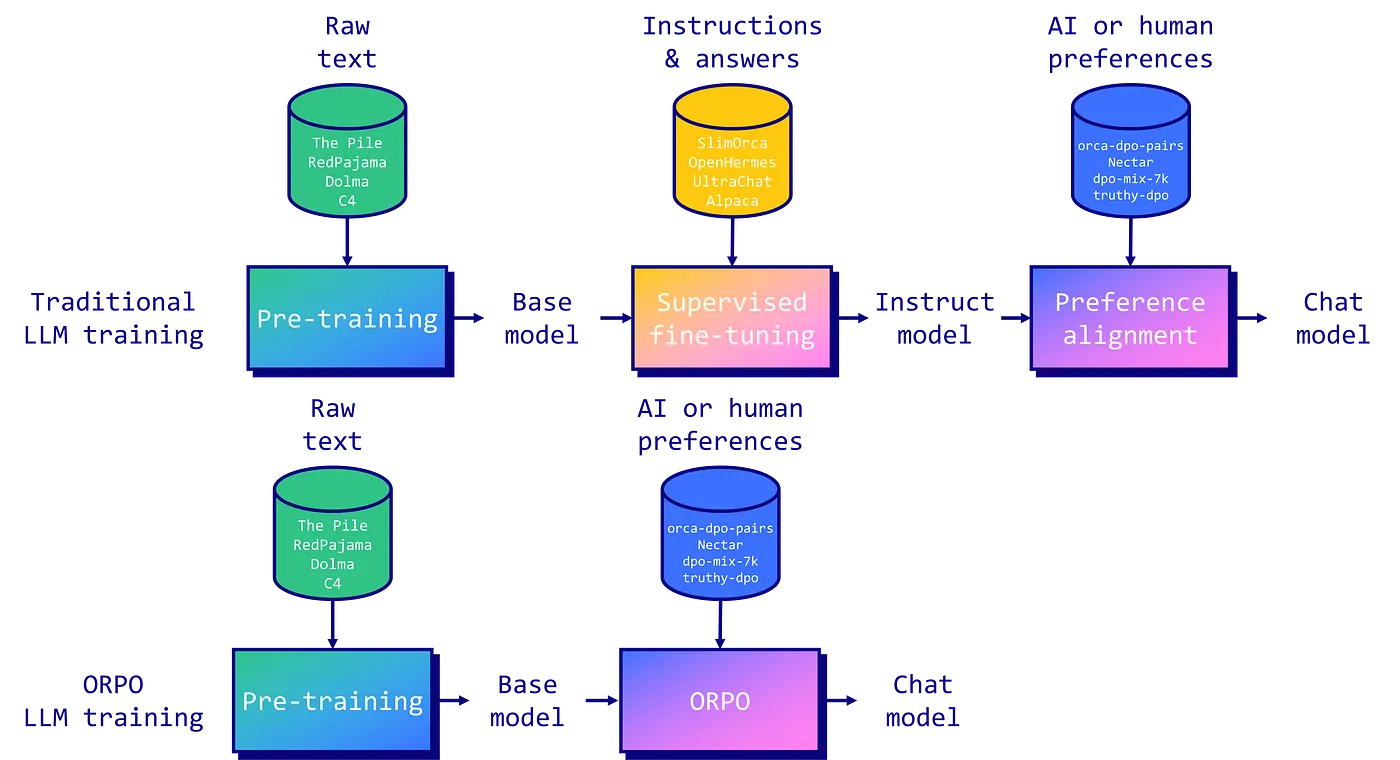

Настройка инструкций и выравнивание предпочтений являются важными техниками адаптации Больших Языковых Моделей (LLM) под конкретные задачи. Традиционно это включает в себя многоступенчатый процесс:

1) Дообучение с учителем (SFT) на инструкциях для адаптации модели к целевой области, за которой следует

2) методы выравнивания предпочтений, такие как Обучение с Подкреплением с Обратной Связью Человека (RLHF) или Прямая Оптимизация Предпочтений (DPO), для увеличения вероятности генерации предпочтительных ответов по сравнению с отклоненными.

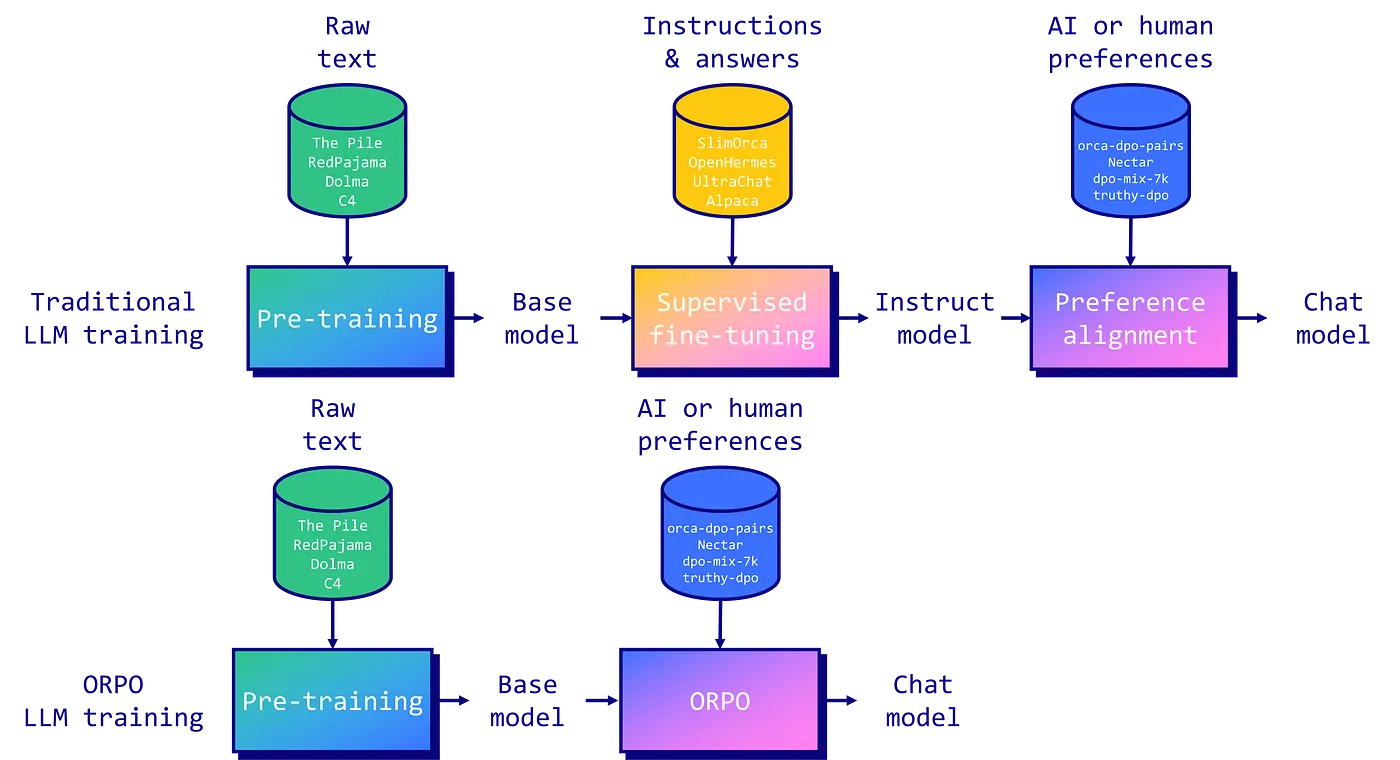

Однако исследователи выявили ограничение этого подхода. В то время как дообучения с учителем (SFT) эффективно адаптирует модель к желаемой области, она дополнительно увеличивает вероятность генерации нежелательных ответов наряду с предпочтительными. Поэтому этап выравнивания предпочтений необходим для увеличения разрыва между вероятностями предпочтительных и отклоненных выводов.

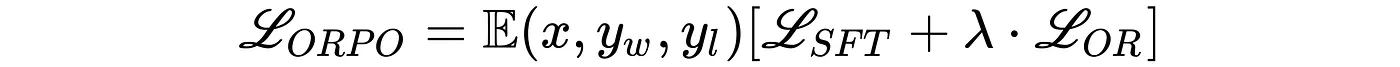

In [ ]:
from datasets import load_dataset
from functools import lru_cache

from transformers import AutoTokenizer


1) Нам нужен токенайзер, у которого есть метод `apply_chat_template` — он превращает список
   сообщений вида [{"role":"user","content":"..."}, ...] в строку-промпт по шаблону чатовой модели.
   У обычного tiktoken такого метода нет, поэтому берём чатовый токенайзер из `transformers`.

2) Мы оборачиваем создание токенайзера в функцию `get_tokenizer()` с кэшированием (@lru_cache).
   Это важно для `datasets.map(..., num_proc=...)`: когда датасет обрабатывается в нескольких
   процессах, каждый воркер сам создаёт СВОЙ экземпляр токенайзера по требованию.
   Так мы избегаем проблем с передачей непиклируемых объектов в процессы и расхождений
   между "глобальной" переменной и её копиями в воркерах.

3) Вспомогательная `_to_messages()` нормализует входные данные датасета:
   - если в поле уже список сообщений — оставляем как есть;
   - если строка — оборачиваем её в одно сообщение от "user".
   Это гарантирует, что `apply_chat_template` всегда получает ожидаемый формат.


In [ ]:
# Возьмём открытую чат-модель с готовым chat template
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

@lru_cache(None)
def get_tokenizer():
    tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    if not hasattr(tok, "apply_chat_template"):
        raise RuntimeError(
            f"У {MODEL_NAME} нет apply_chat_template. Обновите transformers или возьмите чат-модель."
        )
    return tok

def _to_messages(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return [{"role": "user", "content": x}]
    return [{"role": "user", "content": str(x)}]


# обрезка по числу токенов
def truncate_text_to_tokens(text: str, tok, max_tokens: int) -> str:
    ids = tok.encode(text, add_special_tokens=False, truncation=False)
    if len(ids) <= max_tokens:
        return text
    ids = ids[:max_tokens]
    return tok.decode(ids, skip_special_tokens=True)




Зачем токенайзер берём ВНУТРИ функции:

- `datasets.map` может запускать `format_chat_template` в нескольких процессах (num_proc>1).
  Глобальные переменные не синхронизируются между процессами, а объекты токенайзера обычно
  нельзя "пропихнуть" через pickle. Поэтому мы вызываем `get_tokenizer()` внутри функции:
  каждый процесс создаст (и закэширует) свой корректный токенайзер.

- Дальше мы применяем `apply_chat_template` к полям 'chosen' и 'rejected', предварительно
  приведя их к формату сообщений через `_to_messages()`. На выходе получаем готовые промпты
  (строки), с которыми удобно дальше работать при обучении/инференсе.



In [ ]:
MODEL_MAX_LEN = 2048

def format_chat_template(row):
    tok = get_tokenizer()  # создаётся 1 раз на процесс
    ch = tok.apply_chat_template(_to_messages(row["chosen"]), tokenize=False, add_generation_prompt=False)
    rj = tok.apply_chat_template(_to_messages(row["rejected"]), tokenize=False, add_generation_prompt=False)
    # обрезаем до лимита
    ch = truncate_text_to_tokens(ch, tok, MODEL_MAX_LEN)
    rj = truncate_text_to_tokens(rj, tok, MODEL_MAX_LEN)
    row["chosen"] = ch
    row["rejected"] = rj
    return row

In [ ]:
# import os
# import torch

In [ ]:
# Загружаем датасет

dataset_name = "mlabonne/orpo-dpo-mix-40k"
dataset = load_dataset(dataset_name, split="all")
dataset = dataset.shuffle(seed=42).select(range(1000))

# для отладки — без многопроцессности:
# dataset = dataset.map(format_chat_template)
dataset = dataset.map(format_chat_template, num_proc=os.cpu_count())

dataset = dataset.train_test_split(test_size=0.01)

tokenizer = get_tokenizer()  # создастся/возьмётся из кэша
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
tokenizer.model_max_length = MODEL_MAX_LEN

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/127M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44245 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (9917 > 2048). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (2300 > 2048). Running this sequence through the model will result in indexing errors


ORPO требует наличия набора данных предпочтений, включающего подсказку, выбранный ответ и отклоненный ответ. В этом ноутбуке мы будем использовать mlabonne/orpo-dpo-mix-40k, который включает в себя комбинацию следующих высококачественных наборов данных DPO:

- argilla/distilabel-capybara-dpo-7k-binarized: выбранные ответы с высоким рейтингом >=5 (2,882 образца)
- argilla/distilabel-intel-orca-dpo-pairs: выбранные ответы с высоким рейтингом >=9, не в GSM8K (2,299 образцов)
- argilla/ultrafeedback-binarized-preferences-cleaned: выбранные ответы с высоким рейтингом >=5 (22,799 образцов)
- argilla/distilabel-math-preference-dpo: выбранные ответы с высоким рейтингом >=9 (2,181 образец)
- unalignment/toxic-dpo-v0.2 (541 образец)
- M4-ai/prm_dpo_pairs_cleaned (7,958 образцов)
- jondurbin/truthy-dpo-v0.1 (1,016 образцов)

Приступаем к обучению.

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from transformers import AutoConfig, AutoModelForCausalLM

# Безопасный выбор типа тензоров:
# fp16 работает на CUDA, на CPU используем float32, иначе получите ошибку.
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

config = AutoConfig.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    config._name_or_path,
    load_in_8bit=False,
    dtype=DTYPE
)

# Явно переносим модель:
model.to(device)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [ ]:
from peft import LoraConfig, get_peft_model, PeftModel

In [ ]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=['up_proj', 'down_proj', 'gate_proj', 'k_proj', 'q_proj', 'v_proj', 'o_proj']
)

In [ ]:
model = get_peft_model(model, peft_config)
model.config.use_cache = False  # во время обучения
# model.gradient_checkpointing_enable()  # включите при нехватке VRAM

In [ ]:
!pip install trl -qq

In [ ]:
import trl
import math

In [ ]:
use_cuda = torch.cuda.is_available()
optim_name = "adamw_torch"

In [ ]:
per_device_train_batch_size = 2 if use_cuda else 1
gradient_accumulation_steps = 4
global_batch = per_device_train_batch_size * max(1, torch.cuda.device_count()) * gradient_accumulation_steps
steps_per_epoch = max(1, math.ceil(len(dataset["train"]) / max(1, global_batch)))
eval_steps_int = max(1, steps_per_epoch // 5)   # каждые ~20% эпохи

# Создаем конфигурацию для ORPO
orpo_args = trl.ORPOConfig(
    learning_rate=8e-6,
    lr_scheduler_type="linear",
    max_length=512, # 1024,
    max_prompt_length=384, # 512,
    beta=0.1,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=gradient_accumulation_steps,
    optim=optim_name,
    num_train_epochs=1,
    eval_strategy="steps",
    eval_steps=eval_steps_int,
    logging_steps=1,
    warmup_steps=10,
    max_steps = 5,
    output_dir="orpo",
    save_strategy="no",
    report_to=[],
    dataloader_num_workers=2,
    dataloader_pin_memory=torch.cuda.is_available(),
)

# У некоторых версий TRL у ORPOTrainer нет аргумента tokenizer, используем processing_class
trainer = trl.ORPOTrainer(
    model=model,
    args=orpo_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    peft_config=peft_config,
    processing_class=tokenizer,
)


/usr/local/lib/python3.12/dist-packages/trl/trainer/orpo_trainer.py:150: UserWarning: This trainer will soon be moved to trl.experimental and is a candidate for removal. If you rely on it and want it to remain, please share your comments here: https://github.com/huggingface/trl/issues/4223. Silence this warning by setting environment variable TRL_EXPERIMENTAL_SILENCE=1.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Map:   0%|          | 0/990 [00:00<?, ? examples/s]

Map:   0%|          | 0/990 [00:00<?, ? examples/s]

Map:   0%|          | 0/990 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2119 > 2048). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [ ]:
import gc

# Очищаем память
gc.collect()
gc.collect()
torch.cuda.empty_cache()

In [ ]:
trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss


TrainOutput(global_step=5, training_loss=1.338378357887268, metrics={'train_runtime': 90.1411, 'train_samples_per_second': 0.444, 'train_steps_per_second': 0.055, 'total_flos': 0.0, 'train_loss': 1.338378357887268, 'epoch': 0.04040404040404041})

In [ ]:
new_model  = "orpo"
trainer.save_model(new_model)

In [ ]:
del trainer, model
gc.collect()
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Перезагружаем базовую модель и токенизатор
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
fp16_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map="auto",
)

# Обновляем веса базовой модели адаптером
model = PeftModel.from_pretrained(fp16_model, new_model)
model = model.merge_and_unload()

In [ ]:
# (опционально) сохранить слитую модель одним чекпойнтом
# save_dir = "merged-orpo"
# model.save_pretrained(save_dir, safe_serialization=True)
# tokenizer.save_pretrained(save_dir)

Наше дообучение ORPO на самом деле довольно хорошее и улучшает производительность базовой модели на всех тестах. Это обнадеживает и вероятно означает, что дообучение на всем наборе из 40 тысяч образцов приведет к отличным результатам.

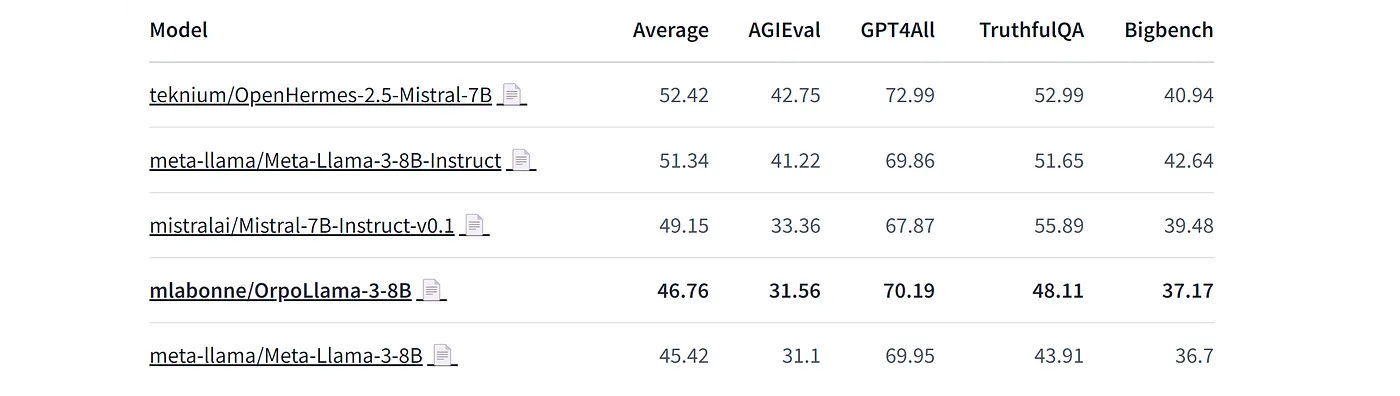

In [ ]:
# import torch, importlib
# print("CUDA:", torch.cuda.is_available(), "GPUs:", torch.cuda.device_count())
# print("bitsandbytes:", importlib.util.find_spec("bitsandbytes") is not None)

In [ ]:
from transformers import GenerationConfig

tokenizer.model_max_length = 2048
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # можно оставить как при обучении


def _norm(enc):
    """Приводим enc (Tensor | BatchEncoding) к dict с input_ids/attention_mask на нужном девайсе."""
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id
    if hasattr(enc, "items"):  # BatchEncoding / dict
        d = {k: v.to(device) for k, v in enc.items()}
        if "attention_mask" not in d:
            d["attention_mask"] = (d["input_ids"] != pad_id).long()
        return d
    if torch.is_tensor(enc):
        ids = enc if enc.dim() == 2 else enc.unsqueeze(0)
        am = (ids != pad_id).long()
        return {"input_ids": ids.to(device), "attention_mask": am.to(device)}
    # на всякий случай
    be = tokenizer(str(enc), return_tensors="pt")
    return {k: v.to(device) for k, v in be.items()}

messages = [
    {"role": "system", "content": "Ты дружелюбный и краткий помощник."},
    {"role": "user",   "content": "Объясни в 2–3 предложениях, что такое большие языковые модели."}
]

enc = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=tokenizer.model_max_length,
)
inputs = _norm(enc)

# (опционально) запретим чужие теги, если они есть в словаре
bad_tokens = ["<|system|>", "<|user|>", "<|assistant|>"]
bwi = [ids for ids in tokenizer(bad_tokens, add_special_tokens=False).input_ids if ids]

gen_cfg = GenerationConfig(
    max_new_tokens=160,
    do_sample=False,
    no_repeat_ngram_size=3,
    repetition_penalty=1.1,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    bad_words_ids=bwi if bwi else None,  # NEW: опционально
)



In [ ]:
model.eval()
with torch.inference_mode():
    out = model.generate(**inputs, generation_config=gen_cfg)

generated = out[0]
prompt_len = inputs["input_ids"].shape[1]
answer_ids = generated[prompt_len:]
print(tokenizer.decode(answer_ids, skip_special_tokens=True))


1. Большие языkovые модели - это компьютерные программы, которые позволяют человеку читать и писать на разных языках. 

2. Большой языковый модель - это система, которая предоставляет человеку возможность изучать и понимать язык, используя различные методы обучения.  В большинстве случаев, эти системы используются для обучения языка на основе речевых данных (например, записи голоса). 
 
3. Большая языковая модель – это система или программа, которая позволяет человеке читаться и писаться на нескольких языках одновременно. Это
